In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
df = pd.read_csv('../data/raw/twitter_sentiment_data.csv')

In [ ]:
print(df.columns)

Index(['sentiment', 'message', 'tweetid'], dtype='str')
          sentiment       tweetid
count  43943.000000  4.394300e+04
mean       0.853924  8.367966e+17
std        0.853543  8.568506e+16
min       -1.000000  5.926334e+17
25%        0.000000  7.970376e+17
50%        1.000000  8.402301e+17
75%        1.000000  9.020003e+17
max        2.000000  9.667024e+17


In [18]:
print('\nShape:', df.shape)
print('\nMissing Values:\n', df.isna().sum())
print('\nDuplicate Text:', df['message'].duplicated().sum())
print('\nSentiment Classes: ', df['sentiment'].nunique(), '->', df['sentiment'].unique())


Shape: (43943, 3)

Missing Values:
 sentiment    0
message      0
tweetid      0
dtype: int64

Duplicate Text: 2910

Sentiment Classes:  4 -> [-1  1  2  0]


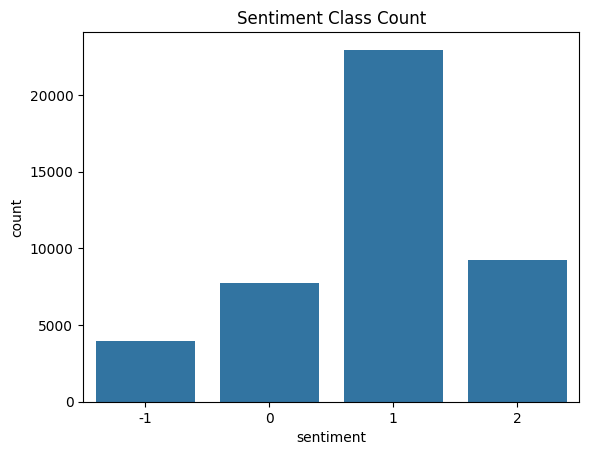

In [ ]:
sns.countplot(df, x='sentiment')
plt.title('Sentiment Class Count')
plt.show()

In [26]:
df['word_count'] = df['message'].str.split().str.len()
df["char_count"] = df["message"].str.len()

print(df[['word_count','char_count']].describe())

         word_count    char_count
count  43943.000000  43943.000000
mean      17.400792    122.823954
std        4.621521     24.720780
min        1.000000      7.000000
25%       14.000000    111.000000
50%       18.000000    133.000000
75%       21.000000    140.000000
max       97.000000    623.000000


In [30]:
empty = df["message"].str.strip().eq("") | df["message"].isna()
print("Empty/whitespace rows:", empty.sum())
print("Very short (<3 words):", (df["word_count"] <= 3).sum())

Empty/whitespace rows: 0
Very short (<3 words): 106


In [31]:
conflict = df.groupby("message")["sentiment"].nunique()
print("Texts with conflicting labels:", (conflict > 1).sum())

Texts with conflicting labels: 8


In [32]:
patterns = {
    "url": r"http\S+|www\.\S+",
    "mention": r"@\w+",
    "hashtag": r"#\w+",
    "number": r"\b\d+\b",
    "upper": r"\b[A-Z]{3,}\b",
}

for name, pat in patterns.items():
    hits = df["message"].str.contains(pat, regex=True, na=False).mean()
    print(f"{name:8s}: {hits:.2%} of rows")

url     : 59.07% of rows
mention : 70.93% of rows
hashtag : 19.01% of rows
number  : 10.82% of rows
upper   : 16.88% of rows
